# Attribution Breakdown by Predicted Activity

This notebook analyzes Integrated Gradients attributions grouped by what activity the model predicted.

For each predicted activity (e.g., EOS, Closed, Take in charge), we examine:
1. Which features (Activity, Resource, etc.) received the most attribution
2. When the Activity feature is attributed, which specific activity VALUES in the prefix contributed most

This helps answer questions like:
- "When the model predicts EOS, what is it looking at?"
- "Does the model use different input patterns for different predictions?"

In [1]:
import sys
import os
from pathlib import Path
import pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
NOTEBOOK_DIR = Path().resolve()
SRC_DIR = NOTEBOOK_DIR.parent.parent  # interpretability/notebooks -> interpretability -> src
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print(f"Source directory: {SRC_DIR}")

from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from aa_philipp.model_with_integrated_gradients.embedder import get_final_process_step
from aa_philipp.model_with_integrated_gradients.targeter import ActivityTargeter
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_decoder_forward_simplified import PSP_Model_simplified
from evaluation.evaluation import Evaluation
from captum.attr import IntegratedGradients

# Set seeds
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

Source directory: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src


## Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Number of samples to analyze (set lower for faster testing)
MAX_SAMPLES = 500  # Increased to get more diversity in predictions

# IG steps (higher = more accurate but slower)
IG_STEPS = 30

# Minimum samples per predicted activity to include in analysis
MIN_SAMPLES_PER_ACTIVITY = 3  # Reduced to include more activity types

# Model and data paths
MODEL_PATH = SRC_DIR / 'notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
DATASET_PATH = SRC_DIR.parent / 'encoded_data/test_philipp/helpdesk_all_5_test.pkl'

print(f"Configuration:")
print(f"  Max samples: {MAX_SAMPLES}")
print(f"  IG steps: {IG_STEPS}")
print(f"  Min samples per activity: {MIN_SAMPLES_PER_ACTIVITY}")

Configuration:
  Max samples: 500
  IG steps: 30
  Min samples per activity: 3


## Load Model and Data

In [3]:
# Load model
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(MODEL_PATH), dropout=0.0)
model.eval()

# Load dataset
dataset = torch.load(str(DATASET_PATH), weights_only=False)

print(f"Model loaded from: {MODEL_PATH.name}")
print(f"Dataset loaded: {len(dataset)} samples")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [4]:
# Setup evaluation helper
evaluation = Evaluation(
    model=model,
    dataset=dataset,
    concept_name='Activity',
    growing_num_values=['case_elapsed_time'],
    all_cat=['Activity', 'Resource'],
    all_num=['case_elapsed_time', 'event_elapsed_time']
)

# Get activity label mapping
activity_idx_to_name = evaluation.inverted_suffix_categories[evaluation.concept_name_id]
activity_name_to_idx = {v: k for k, v in activity_idx_to_name.items()}

prefix_cat_attributes = evaluation.prefix_cat_attributes
print(f"\nActivity classes ({len(activity_idx_to_name)}):")
for idx, name in sorted(activity_idx_to_name.items()):
    print(f"  {idx}: {name}")

print(f"\nPrefix categorical attributes: {prefix_cat_attributes}")


Activity classes (15):
  1: Assign seriousness
  2: Closed
  3: Create SW anomaly
  4: DUPLICATE
  5: EOS
  6: INVALID
  7: Insert ticket
  8: RESOLVED
  9: Require upgrade
  10: Resolve SW anomaly
  11: Resolve ticket
  12: Schedule intervention
  13: Take in charge ticket
  14: VERIFIED
  15: Wait

Prefix categorical attributes: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']


## Helper Functions

In [5]:
def forward_for_ig(model, prefix, target_fn):
    """Forward function for Integrated Gradients."""
    simplified_model = PSP_Model_simplified(model=model)
    predictions = simplified_model.forward(prefix=prefix)
    target = target_fn(predictions)
    return target


def full_forward(model, prefix):
    """Get full model prediction for a prefix."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach().requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach().requires_grad_(True)

    pred = forward_for_ig(
        model=model,
        prefix=(prefixes_embedded, final_prefix_element_embedded),
        target_fn=lambda x: x,
    )
    return pred


def compute_ig_attributions_with_timesteps(model, prefix, prefix_len, target_activity_idx, n_steps=30):
    """
    Compute Integrated Gradients attributions with per-timestep breakdown.
    
    Returns:
        dict with:
        - 'feature_attrs': {feature_name: total_attribution}
        - 'timestep_attrs': list of {feature_name: attribution} for each timestep
        - 'activity_values': list of activity indices at each timestep
    """
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach().requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach().requires_grad_(True)

    baselines = (
        torch.zeros_like(prefixes_embedded),
        torch.zeros_like(final_prefix_element_embedded)
    )

    activity_targeter = ActivityTargeter(activity_index=target_activity_idx)

    ig = IntegratedGradients(
        lambda x1, x2: forward_for_ig(
            model=model,
            prefix=(x1, x2),
            target_fn=activity_targeter.target_fn,
        ),
    )

    attributions, _ = ig.attribute(
        inputs=(prefixes_embedded, final_prefix_element_embedded),
        baselines=baselines,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # Merge encoder and decoder attributions
    seq_len = prefixes_embedded.shape[0]
    embed_dim = min(attributions[0].shape[2], attributions[1].shape[2])
    attributions[0][seq_len - 1, :, :embed_dim] += attributions[1][0, :, :embed_dim]
    
    attr_tensor = attributions[0].squeeze(1)  # Remove batch dim
    
    # Extract activity values from prefix
    activity_tensor = prefix[0][evaluation.concept_name_id]  # Activity tensor
    full_seq_len = activity_tensor.shape[1]
    start_idx = full_seq_len - prefix_len
    
    activity_values = []
    for t in range(prefix_len):
        act_idx = activity_tensor[0, start_idx + t].item()
        activity_values.append(act_idx)
    
    # Extract per-feature attributions for each timestep
    timestep_attrs = []
    feature_totals = defaultdict(float)
    
    for t in range(prefix_len):
        t_attr = t - prefix_len  # Negative index into attr_tensor
        timestep_dict = {}
        
        start_index = 0
        for idx, encoded_attribute in enumerate(prefix_cat_attributes):
            embedding_dim = model.encoder.embeddings[idx].embedding_dim
            # Sum absolute attribution across embedding dimension
            feat_attr = attr_tensor[t_attr, start_index:start_index + embedding_dim].abs().sum().item()
            timestep_dict[encoded_attribute] = feat_attr
            feature_totals[encoded_attribute] += feat_attr
            start_index += embedding_dim
        
        timestep_attrs.append(timestep_dict)
    
    return {
        'feature_attrs': dict(feature_totals),
        'timestep_attrs': timestep_attrs,
        'activity_values': activity_values
    }

## Compute Attributions

In [6]:
# Collect samples
cases = evaluation._get_cases_from_dataset()
case_items = list(evaluation.cases.items())

# Prepare samples
all_samples = []
for case_name, full_case in case_items:
    for prefix_len, prefix, suffix in evaluation._iterate_case(full_case):
        all_samples.append((case_name, prefix_len, prefix, suffix))

# Limit samples if configured
if MAX_SAMPLES is not None:
    random.shuffle(all_samples)
    all_samples = all_samples[:MAX_SAMPLES]

print(f"Processing {len(all_samples)} samples...")

# Compute attributions
results = []

for case_name, prefix_len, prefix, suffix in tqdm(all_samples, desc="Computing attributions"):
    try:
        # Get prediction
        pred = full_forward(model, prefix)
        activity_logits = pred[0][0]["Activity_mean"][0]
        predicted_activity_idx = activity_logits.argmax().item()
        predicted_activity_name = activity_idx_to_name.get(predicted_activity_idx, f"ID_{predicted_activity_idx}")
        prediction_confidence = torch.softmax(activity_logits, dim=0)[predicted_activity_idx].item()
        
        # Compute attributions
        attr_result = compute_ig_attributions_with_timesteps(
            model, prefix, prefix_len, predicted_activity_idx, n_steps=IG_STEPS
        )
        
        results.append({
            'case_name': case_name,
            'prefix_len': prefix_len,
            'predicted_activity_idx': predicted_activity_idx,
            'predicted_activity_name': predicted_activity_name,
            'prediction_confidence': prediction_confidence,
            'feature_attrs': attr_result['feature_attrs'],
            'timestep_attrs': attr_result['timestep_attrs'],
            'activity_values': attr_result['activity_values']
        })
        
    except Exception as e:
        print(f"Error for {case_name}: {e}")

print(f"\nComputed attributions for {len(results)} samples")

Processing 500 samples...


Computing attributions:   0%|          | 0/500 [00:00<?, ?it/s]


Computed attributions for 500 samples


## Analysis: Attribution by Predicted Activity

In [7]:
# Group results by predicted activity
results_by_prediction = defaultdict(list)
for r in results:
    results_by_prediction[r['predicted_activity_name']].append(r)

# Filter to activities with enough samples
valid_predictions = {k: v for k, v in results_by_prediction.items() 
                     if len(v) >= MIN_SAMPLES_PER_ACTIVITY}

print(f"Predictions with >= {MIN_SAMPLES_PER_ACTIVITY} samples:")
for pred_name, samples in sorted(valid_predictions.items(), key=lambda x: -len(x[1])):
    print(f"  {pred_name}: {len(samples)} samples")

Predictions with >= 3 samples:
  Closed: 486 samples
  Resolve ticket: 8 samples
  EOS: 6 samples


In [8]:
def compute_attribution_breakdown(samples):
    """
    For a list of samples, compute:
    1. Mean attribution per feature
    2. When Activity feature is attributed, which activity values contributed
    """
    # Aggregate feature attributions
    feature_attrs_list = [s['feature_attrs'] for s in samples]
    all_features = set()
    for fa in feature_attrs_list:
        all_features.update(fa.keys())
    
    feature_means = {}
    feature_stds = {}
    for feat in all_features:
        values = [fa.get(feat, 0) for fa in feature_attrs_list]
        feature_means[feat] = np.mean(values)
        feature_stds[feat] = np.std(values)
    
    # Normalize to percentages
    total_attr = sum(feature_means.values())
    if total_attr > 0:
        feature_pcts = {k: v / total_attr * 100 for k, v in feature_means.items()}
    else:
        feature_pcts = {k: 0 for k in feature_means}
    
    # Activity value breakdown
    # For each sample, get the activity attribution at each timestep and the activity value
    activity_value_attrs = defaultdict(list)  # activity_name -> list of attributions
    
    for sample in samples:
        timestep_attrs = sample['timestep_attrs']
        activity_values = sample['activity_values']
        
        for t, (ts_attr, act_idx) in enumerate(zip(timestep_attrs, activity_values)):
            if act_idx == 0:  # Skip padding
                continue
            act_name = activity_idx_to_name.get(act_idx, f"ID_{act_idx}")
            act_attr = ts_attr.get('Activity', 0)
            activity_value_attrs[act_name].append(act_attr)
    
    # Compute mean attribution per activity value
    activity_value_means = {}
    for act_name, attrs in activity_value_attrs.items():
        activity_value_means[act_name] = {
            'mean_attr': np.mean(attrs),
            'count': len(attrs),
            'total_attr': np.sum(attrs)
        }
    
    # Normalize activity value attributions to percentages
    total_activity_attr = sum(v['total_attr'] for v in activity_value_means.values())
    if total_activity_attr > 0:
        for act_name in activity_value_means:
            activity_value_means[act_name]['pct'] = (
                activity_value_means[act_name]['total_attr'] / total_activity_attr * 100
            )
    
    return {
        'n_samples': len(samples),
        'feature_means': feature_means,
        'feature_stds': feature_stds,
        'feature_pcts': feature_pcts,
        'activity_value_breakdown': activity_value_means
    }


# Compute breakdown for each predicted activity
breakdowns = {}
for pred_name, samples in valid_predictions.items():
    breakdowns[pred_name] = compute_attribution_breakdown(samples)

print(f"Computed breakdowns for {len(breakdowns)} predicted activities")

Computed breakdowns for 3 predicted activities


## Results: Feature Attribution by Predicted Activity

In [9]:
# Display feature attribution breakdown for each predicted activity
print("="*100)
print("FEATURE ATTRIBUTION BREAKDOWN BY PREDICTED ACTIVITY")
print("="*100)

# Sort by number of samples
sorted_predictions = sorted(breakdowns.items(), key=lambda x: -x[1]['n_samples'])

for pred_name, breakdown in sorted_predictions:
    print(f"\n{'='*100}")
    print(f"PREDICTED: {pred_name} (n={breakdown['n_samples']} samples)")
    print("="*100)
    
    # Feature breakdown
    print(f"\n--- Feature Attribution (% of total) ---")
    sorted_features = sorted(breakdown['feature_pcts'].items(), key=lambda x: -x[1])
    for feat, pct in sorted_features[:6]:  # Top 6 features
        bar = '#' * int(pct / 2)
        print(f"  {feat:25s}: {pct:5.1f}% {bar}")
    
    # Activity value breakdown
    print(f"\n--- Activity Value Breakdown (when Activity feature is attributed) ---")
    act_breakdown = breakdown['activity_value_breakdown']
    sorted_acts = sorted(act_breakdown.items(), key=lambda x: -x[1].get('pct', 0))
    
    for act_name, stats in sorted_acts[:8]:  # Top 8 activity values
        pct = stats.get('pct', 0)
        count = stats['count']
        bar = '#' * int(pct / 2)
        print(f"  {act_name:25s}: {pct:5.1f}% (n={count:4d}) {bar}")

FEATURE ATTRIBUTION BREAKDOWN BY PREDICTED ACTIVITY

PREDICTED: Closed (n=486 samples)

--- Feature Attribution (% of total) ---
  Activity                 :  51.5% #########################
  Resource                 :  34.5% #################
  Variant index            :  13.7% ######
  customer                 :   0.2% 
  product                  :   0.0% 
  service_level            :   0.0% 

--- Activity Value Breakdown (when Activity feature is attributed) ---
  Resolve ticket           :  99.9% (n= 516) #################################################
  Take in charge ticket    :   0.0% (n= 331) 
  Wait                     :   0.0% (n= 142) 
  Assign seriousness       :   0.0% (n= 150) 
  Require upgrade          :   0.0% (n=   7) 
  Insert ticket            :   0.0% (n=   3) 
  Create SW anomaly        :   0.0% (n=   2) 

PREDICTED: Resolve ticket (n=8 samples)

--- Feature Attribution (% of total) ---
  Activity                 :  51.2% #########################
  Resource   

## Visualization

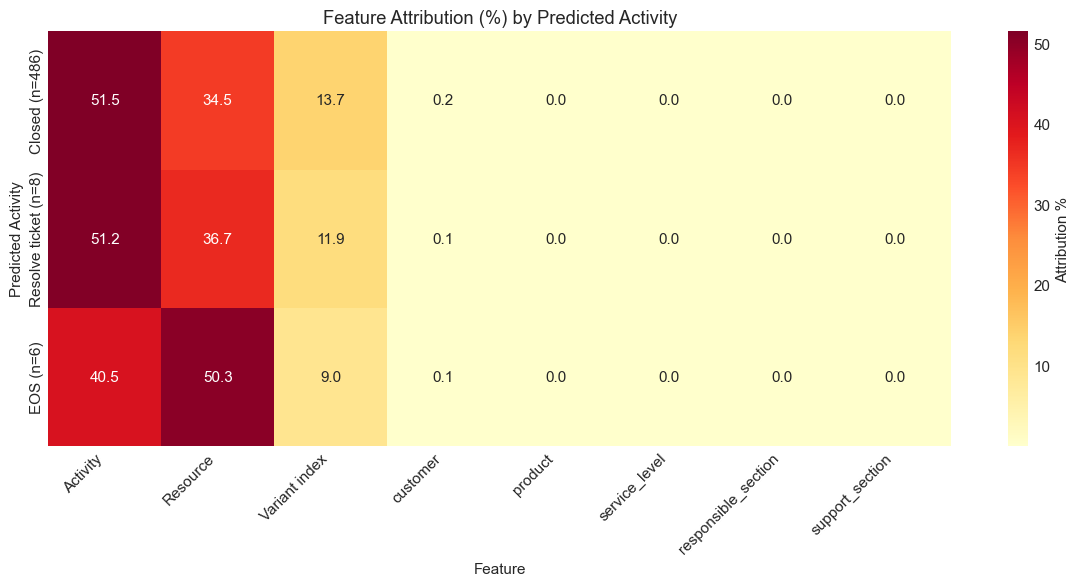

In [10]:
# Create heatmap: Predicted Activity vs Feature Attribution
predictions = list(breakdowns.keys())
# Get top features (by average attribution across all predictions)
all_features = set()
for b in breakdowns.values():
    all_features.update(b['feature_pcts'].keys())

# Sort features by average attribution
feature_avg = {}
for feat in all_features:
    values = [b['feature_pcts'].get(feat, 0) for b in breakdowns.values()]
    feature_avg[feat] = np.mean(values)
top_features = sorted(feature_avg.keys(), key=lambda x: -feature_avg[x])[:8]

# Build matrix
matrix = np.zeros((len(predictions), len(top_features)))
for i, pred in enumerate(predictions):
    for j, feat in enumerate(top_features):
        matrix[i, j] = breakdowns[pred]['feature_pcts'].get(feat, 0)

# Sort predictions by number of samples
pred_order = sorted(range(len(predictions)), 
                    key=lambda i: -breakdowns[predictions[i]]['n_samples'])
predictions_sorted = [predictions[i] for i in pred_order]
matrix_sorted = matrix[pred_order, :]

# Add sample counts to labels
pred_labels = [f"{p} (n={breakdowns[p]['n_samples']})" for p in predictions_sorted]

fig, ax = plt.subplots(figsize=(12, max(6, len(predictions) * 0.5)))
im = sns.heatmap(matrix_sorted, annot=True, fmt='.1f', cmap='YlOrRd',
                 xticklabels=top_features, yticklabels=pred_labels,
                 ax=ax, cbar_kws={'label': 'Attribution %'})
ax.set_xlabel('Feature')
ax.set_ylabel('Predicted Activity')
ax.set_title('Feature Attribution (%) by Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

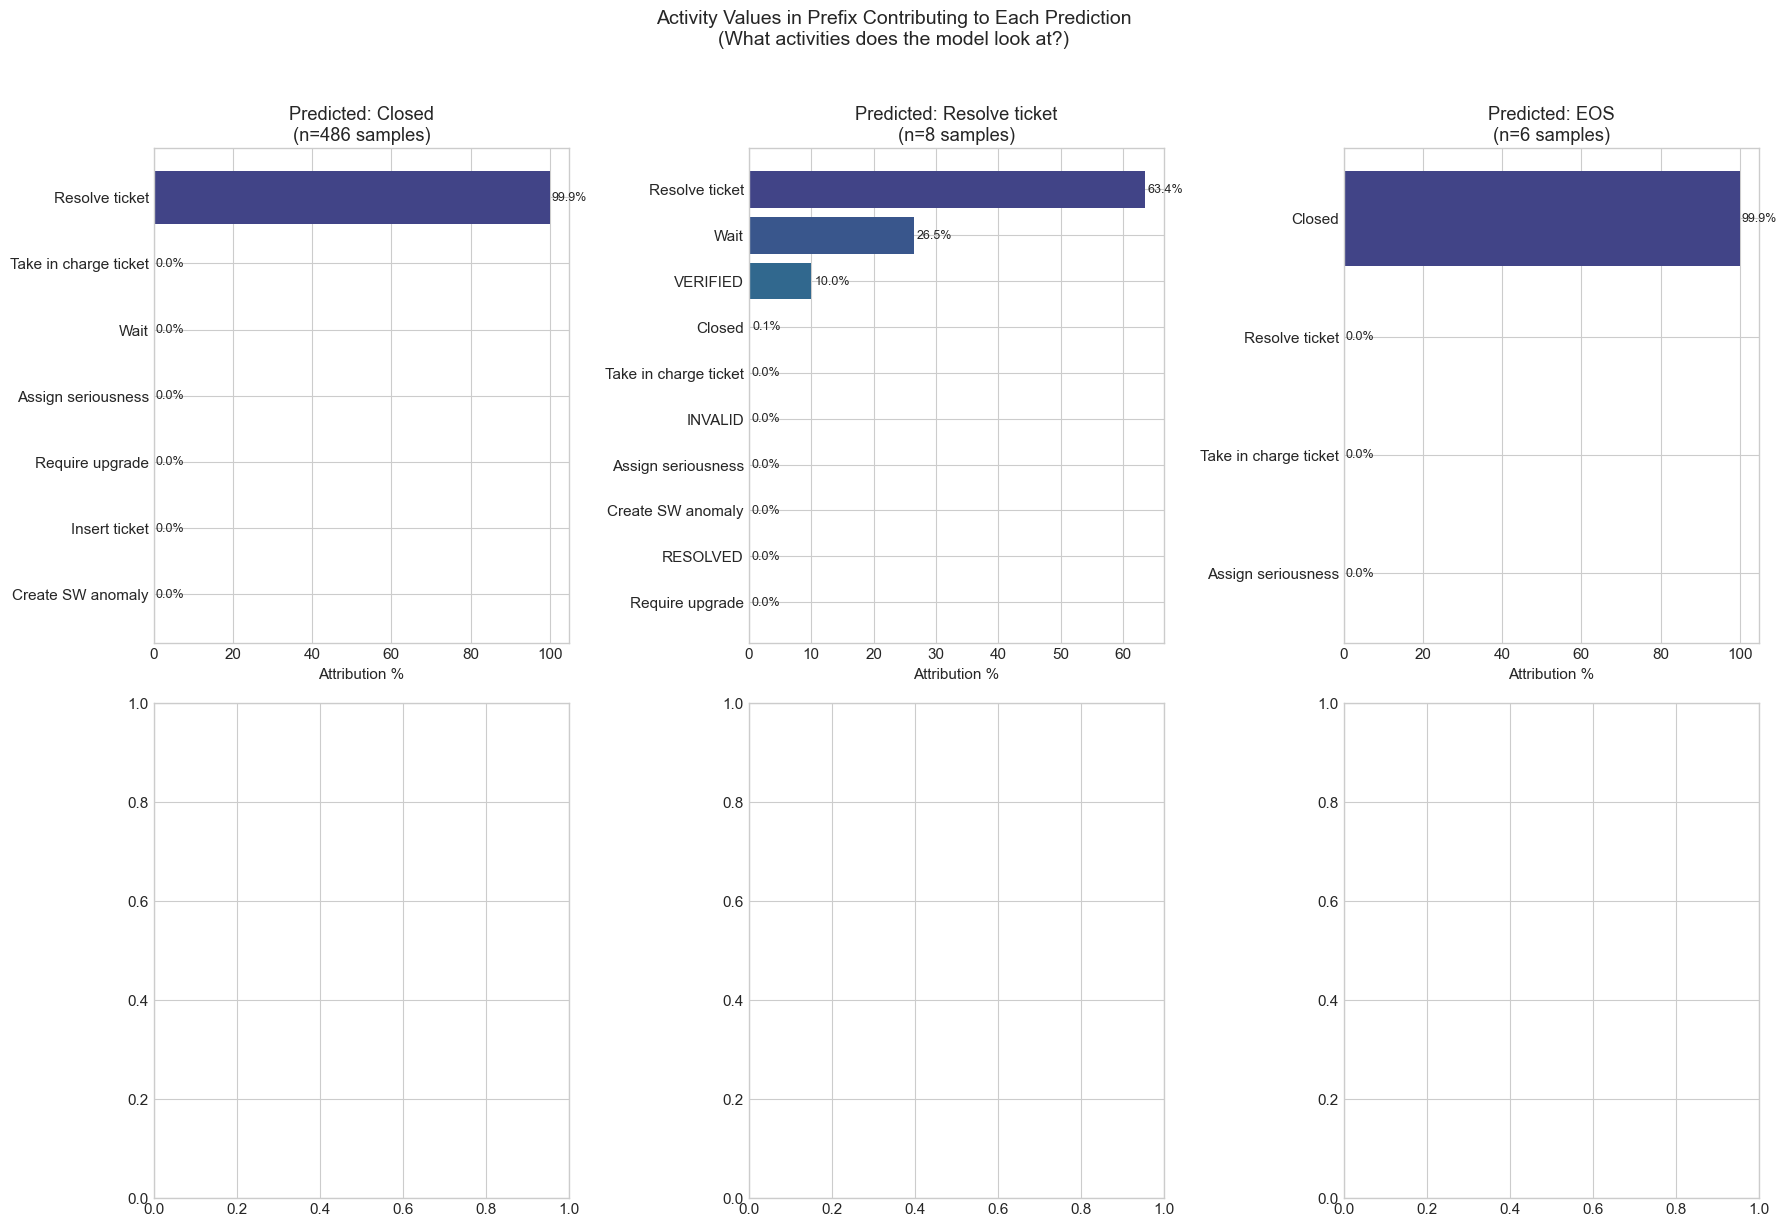

In [11]:
# Create detailed plots for top predicted activities
top_predictions = sorted(breakdowns.keys(), key=lambda x: -breakdowns[x]['n_samples'])[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, pred_name in enumerate(top_predictions):
    ax = axes[idx]
    breakdown = breakdowns[pred_name]
    
    # Get activity value breakdown
    act_breakdown = breakdown['activity_value_breakdown']
    sorted_acts = sorted(act_breakdown.items(), key=lambda x: -x[1].get('pct', 0))[:10]
    
    act_names = [a[0] for a in sorted_acts]
    act_pcts = [a[1].get('pct', 0) for a in sorted_acts]
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(act_names)))
    bars = ax.barh(range(len(act_names)), act_pcts, color=colors)
    ax.set_yticks(range(len(act_names)))
    ax.set_yticklabels(act_names)
    ax.set_xlabel('Attribution %')
    ax.set_title(f'Predicted: {pred_name}\n(n={breakdown["n_samples"]} samples)')
    ax.invert_yaxis()
    
    # Add percentage labels
    for bar, pct in zip(bars, act_pcts):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)

plt.suptitle('Activity Values in Prefix Contributing to Each Prediction\n(What activities does the model look at?)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Detailed Summary Table

In [12]:
# Create summary table
summary_data = []

for pred_name in sorted(breakdowns.keys(), key=lambda x: -breakdowns[x]['n_samples']):
    breakdown = breakdowns[pred_name]
    
    # Top feature
    top_feat = max(breakdown['feature_pcts'].items(), key=lambda x: x[1])
    
    # Top activity values
    act_breakdown = breakdown['activity_value_breakdown']
    sorted_acts = sorted(act_breakdown.items(), key=lambda x: -x[1].get('pct', 0))[:3]
    top_acts = ", ".join([f"{a[0]} ({a[1].get('pct', 0):.1f}%)" for a in sorted_acts])
    
    summary_data.append({
        'Predicted Activity': pred_name,
        'N Samples': breakdown['n_samples'],
        'Top Feature': f"{top_feat[0]} ({top_feat[1]:.1f}%)",
        'Activity %': breakdown['feature_pcts'].get('Activity', 0),
        'Resource %': breakdown['feature_pcts'].get('Resource', 0),
        'Top Activity Values in Prefix': top_acts
    })

summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE")
print("="*120)
display(summary_df)


SUMMARY TABLE


,Predicted Activity,N Samples,Top Feature,Activity %,Resource %,Top Activity Values in Prefix
0,Closed,486,Activity (51.5%),51.457882,34.469692,"Resolve ticket (99.9%), Take in charge ticket ..."
1,Resolve ticket,8,Activity (51.2%),51.201089,36.656622,"Resolve ticket (63.4%), Wait (26.5%), VERIFIED..."
2,EOS,6,Resource (50.3%),40.514922,50.278484,"Closed (99.9%), Resolve ticket (0.0%), Take in..."


In [13]:
# Print human-readable interpretation
print("\n" + "="*100)
print("INTERPRETATION: What does the model look at for each prediction?")
print("="*100)

for pred_name in sorted(breakdowns.keys(), key=lambda x: -breakdowns[x]['n_samples']):
    breakdown = breakdowns[pred_name]
    n = breakdown['n_samples']
    
    # Top feature
    sorted_feats = sorted(breakdown['feature_pcts'].items(), key=lambda x: -x[1])
    top_feat_name, top_feat_pct = sorted_feats[0]
    
    # Top activity values
    act_breakdown = breakdown['activity_value_breakdown']
    sorted_acts = sorted(act_breakdown.items(), key=lambda x: -x[1].get('pct', 0))[:3]
    
    print(f"\n>>> When predicting '{pred_name}' (n={n}):")
    print(f"    The model mainly looks at: {top_feat_name} ({top_feat_pct:.1f}% of attribution)")
    
    if top_feat_name == 'Activity' and sorted_acts:
        print(f"    The Activity values it focuses on are:")
        for act_name, stats in sorted_acts:
            print(f"      - '{act_name}': {stats.get('pct', 0):.1f}%")
    elif sorted_acts:
        print(f"    When looking at Activity values, it focuses on:")
        for act_name, stats in sorted_acts:
            print(f"      - '{act_name}': {stats.get('pct', 0):.1f}%")


INTERPRETATION: What does the model look at for each prediction?

>>> When predicting 'Closed' (n=486):
    The model mainly looks at: Activity (51.5% of attribution)
    The Activity values it focuses on are:
      - 'Resolve ticket': 99.9%
      - 'Take in charge ticket': 0.0%
      - 'Wait': 0.0%

>>> When predicting 'Resolve ticket' (n=8):
    The model mainly looks at: Activity (51.2% of attribution)
    The Activity values it focuses on are:
      - 'Resolve ticket': 63.4%
      - 'Wait': 26.5%
      - 'VERIFIED': 10.0%

>>> When predicting 'EOS' (n=6):
    The model mainly looks at: Resource (50.3% of attribution)
    When looking at Activity values, it focuses on:
      - 'Closed': 99.9%
      - 'Resolve ticket': 0.0%
      - 'Take in charge ticket': 0.0%


## Save Results

In [14]:
# Save results
output_path = 'attribution_by_predicted_activity_results.pkl'
with open(output_path, 'wb') as f:
    pickle.dump({
        'results': results,
        'breakdowns': breakdowns,
        'config': {
            'max_samples': MAX_SAMPLES,
            'ig_steps': IG_STEPS,
            'min_samples_per_activity': MIN_SAMPLES_PER_ACTIVITY
        }
    }, f)
print(f"Results saved to: {output_path}")

Results saved to: attribution_by_predicted_activity_results.pkl
